In [26]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv('data.csv')

In [28]:
df.columns = df.columns.str.strip()

In [29]:
df.shape

(6819, 96)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate            

In [31]:
print("Missing values:",df.isnull().sum().sum())
print("Duplicated values:",df.duplicated().sum())

# Dataset is clear, since there is no any missing or duplicated value

Missing values: 0
Duplicated values: 0


In [32]:
nunique = df.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print(constant_cols)

print(df['Net Income Flag'].nunique())
# In column "Net Income Flag" all values are the same, so you can delete this column

df = df.drop(columns='Net Income Flag')

['Net Income Flag']
1


In [33]:
print(df['Bankrupt?'].value_counts(normalize=True))

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


Text(0, 0.5, 'Number of companies')

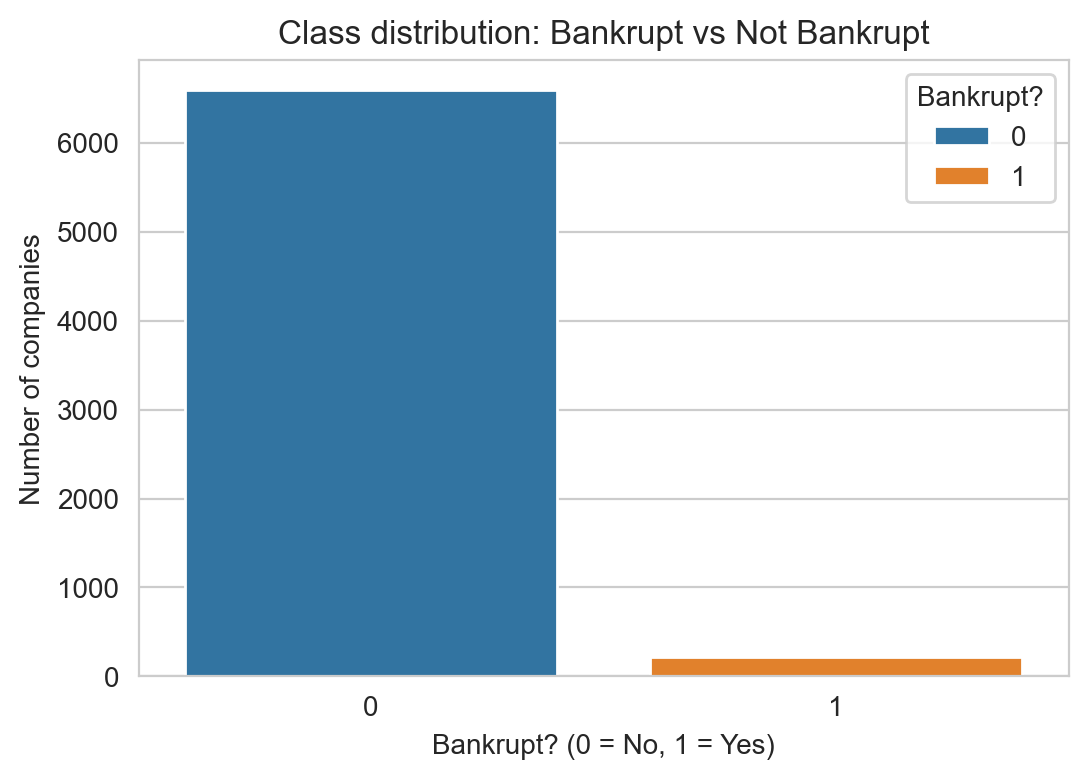

In [34]:
plt.figure(figsize=(6,4), dpi=200)
sns.countplot(x=df['Bankrupt?'], hue=df['Bankrupt?'])

plt.title('Class distribution: Bankrupt vs Not Bankrupt')
plt.xlabel('Bankrupt? (0 = No, 1 = Yes)')
plt.ylabel('Number of companies')

The dataset is highly imbalanced — bankrupt companies make up only ~3.2% of all records. As a result, accuracy is not a reliable metric: a model that always predicts "not bankrupt" would already achieve ~97% accuracy while being completely useless in practice (it would catch zero actual bankruptcies). Because of this, model evaluation in this project relies on metrics that account for class imbalance — recall, precision, F1-score, ROC-AUC, and PR-AUC — with particular attention to recall on the bankrupt class, since failing to detect a real bankruptcy is the costliest type of error here.

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Net Income to Stockholder's Equity,6819.0,0.840402,0.014523,0.0,0.840115,0.841179,0.842357,1.0
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0


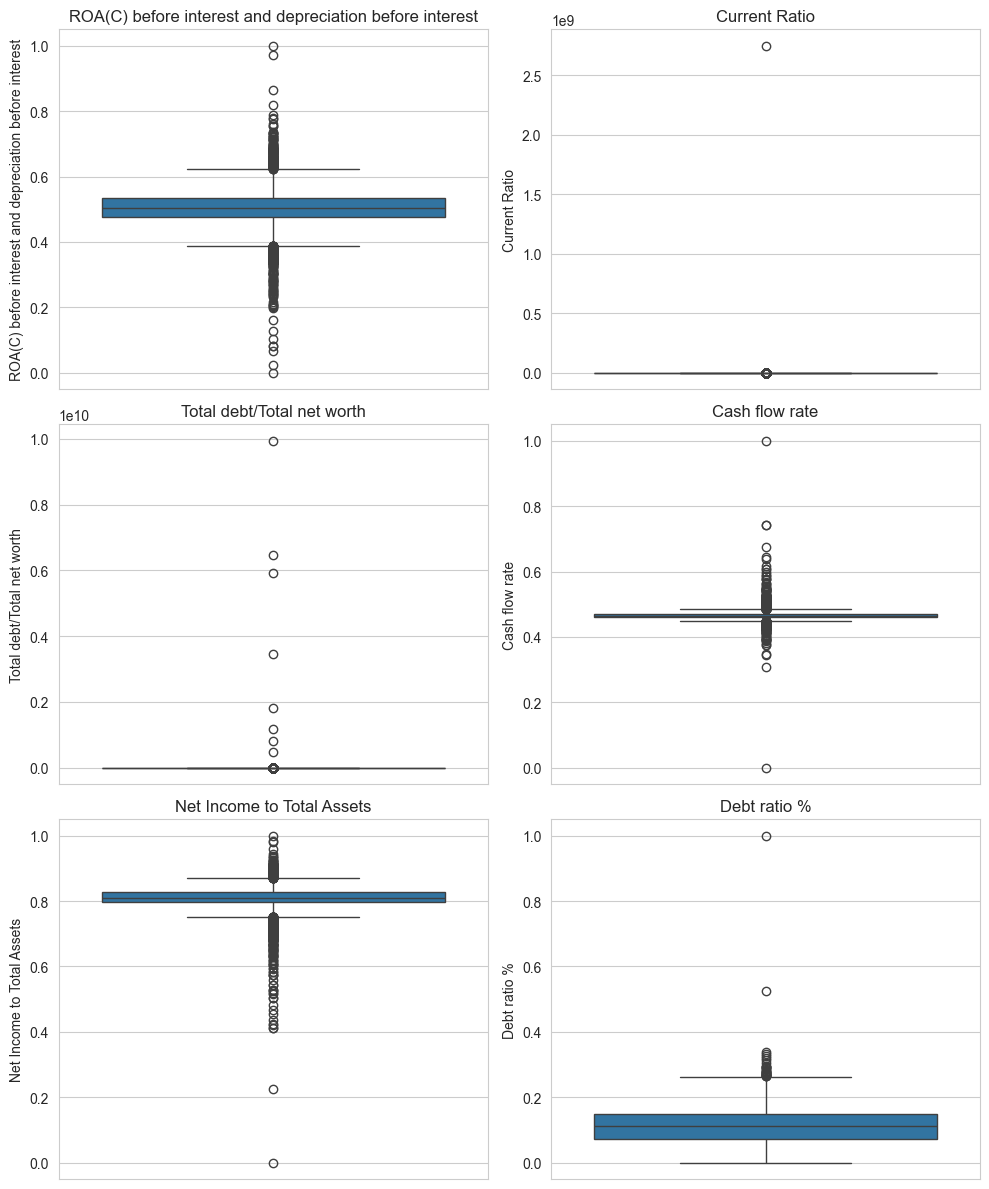

In [36]:
features = [
    'ROA(C) before interest and depreciation before interest',
    'Current Ratio',
    'Total debt/Total net worth',
    'Cash flow rate',
    'Net Income to Total Assets',
    'Debt ratio %'
]

plt.figure(figsize=(10, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df[feature])
    plt.title(feature)
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [37]:
df[['Bankrupt?','Total debt/Total net worth']].sort_values(by='Total debt/Total net worth', ascending=False).head(8)

,Bankrupt?,Total debt/Total net worth
2200,0,9.940000e+09
5288,0,6.470000e+09
2247,0,5.930000e+09
1171,1,3.470000e+09
3180,0,1.820000e+09
2345,0,1.190000e+09
2296,0,8.210000e+08
2490,0,4.740000e+08


Only 1 of 8 companies with such high Total deby / Total Net Worth ratio is bankrupt.

<Axes: xlabel='ROA(C) before interest and depreciation before interest', ylabel='Count'>

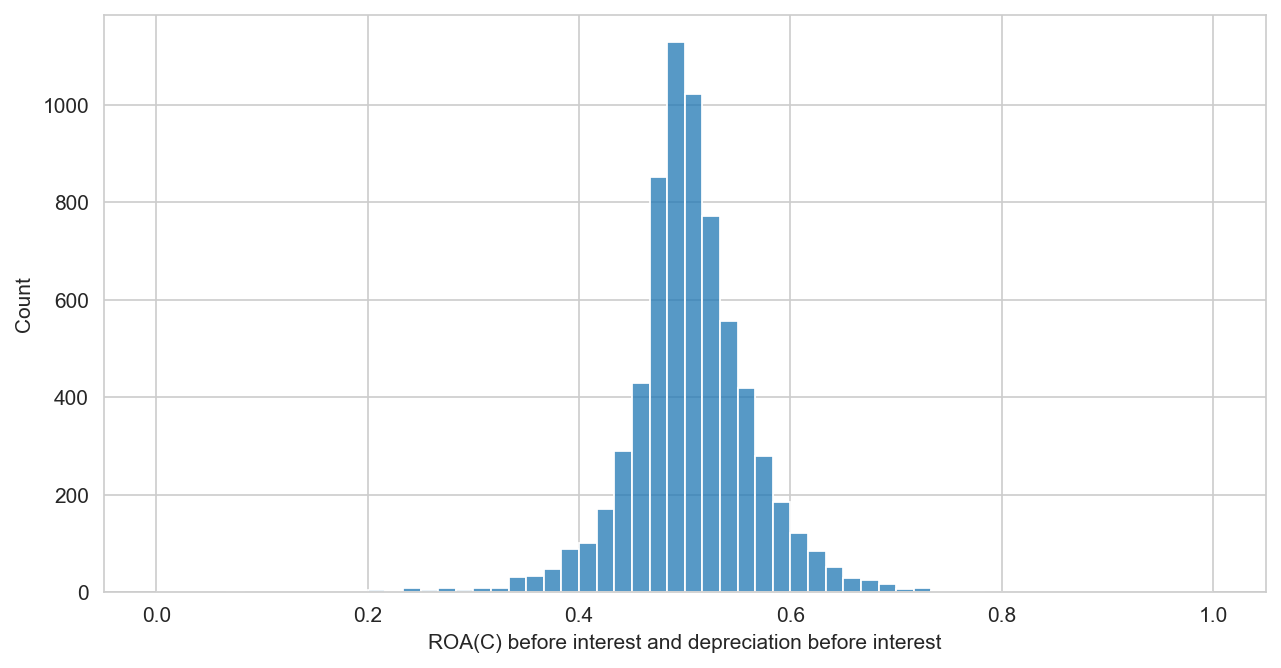

In [38]:
plt.figure(figsize=(10,5), dpi=150)
sns.histplot(x=df['ROA(C) before interest and depreciation before interest'], bins=60)

In [39]:
skew_count = (df.drop('Bankrupt?', axis=1).skew().abs() > 10).sum()
print(skew_count)

48


In [40]:
df.drop('Bankrupt?', axis=1).skew().abs().sort_values(ascending=False).head(20)

Fixed Assets to Assets                     82.577237
Current Ratio                              82.577237
Total income/Total expense                 82.332424
Net Value Growth Rate                      80.291844
Contingent liabilities/Net worth           79.670620
Realized Sales Gross Profit Growth Rate    77.925109
Operating Profit Growth Rate               71.688950
Operating Profit Rate                      70.237164
Continuous Net Profit Growth Rate          67.097534
Total Asset Return Growth Rate Ratio       62.499961
Revenue per person                         59.434480
Continuous interest rate (after tax)       53.200121
After-tax net Interest Rate                52.995744
Pre-tax net Interest Rate                  52.482867
Quick Assets/Current Liability             47.947300
Cash Flow to Sales                         47.869112
Total debt/Total net worth                 46.355336
Degree of Financial Leverage (DFL)         45.724197
Inventory/Working Capital                  45.

The top 15 features with the highest skew are the columns most likely to contain extreme outliers or anomalies, so these should be prioritized for data cleaning and preprocessing to improve model quality.▍

In [41]:
df[['Fixed Assets to Assets', 'Current Ratio']].nlargest(3, 'Current Ratio')

,Fixed Assets to Assets,Current Ratio
2499,0.057384,2.750000e+09
2490,0.000000,1.000000e+00
2393,0.000905,7.126299e-01


In [42]:
top15_features = df.corr()['Bankrupt?'].drop('Bankrupt?').sort_values(key=abs, ascending=False).head(15)
top15_features

Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Debt ratio %                                               0.250161
Persistent EPS in the Last Four Seasons                   -0.219560
Retained Earnings to Total Assets                         -0.217779
Net profit before tax/Paid-in capital                     -0.207857
Per Share Net profit before tax (Yuan Â¥)                 -0.201395
Current Liability to Assets                                0.194494
Working Capital to Total Assets                           -0.193083
Net Income to Stockholder's Equity                        -0.180987
Borrowing dependency                                       0.176543
Current Liability to Current Assets             

In [43]:
corr_full = df.drop(columns=['Bankrupt?']).corr()

# True only above the diagonal (excludes diagonal and lower triangle)
mask = np.triu(np.ones(corr_full.shape), k=1).astype(bool)

# Keep only the upper triangle, everything else becomes NaN
upper = corr_full.where(mask)

# Unstack the matrix into Series, drop NaNs
pairs = upper.unstack().dropna()

# Filter by absolute correlation strength, sort descending
strong_pairs = pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False)
print(strong_pairs)
print('Number of pairs:', len(strong_pairs))

Current Liability to Equity                        Current Liabilities/Equity                                 1.000000
Current Liability to Liability                     Current Liabilities/Liability                              1.000000
Net worth/Assets                                   Debt ratio %                                              -1.000000
Gross Profit to Sales                              Operating Gross Margin                                     1.000000
Net Value Per Share (C)                            Net Value Per Share (A)                                    0.999837
Realized Sales Gross Margin                        Operating Gross Margin                                     0.999518
Gross Profit to Sales                              Realized Sales Gross Margin                                0.999518
Net Value Per Share (A)                            Net Value Per Share (B)                                    0.999342
Net Value Per Share (C)                         

The next step is to remove the parameters that are multicollinear.

In [44]:
columns_to_drop_multicollinearity = [
    # Group 1 — ROA variants (keep: Net Income to Total Assets)
    'ROA(A) before interest and % after tax',
    'ROA(B) before interest and depreciation after tax',
    'ROA(C) before interest and depreciation before interest',
    # Group 2 — Net Value Per Share (keep: A)
    'Net Value Per Share (B)',
    'Net Value Per Share (C)',
    # Group 3a — Debt/Net worth, perfect -1.0 correlation (keep: Net worth/Assets)
    'Debt ratio %',
    # Group 3b — Liability/Equity duplicates (keep: Liability to Equity)
    'Current Liabilities/Equity',
    'Current Liability to Equity',
    'Current Liabilities/Liability',
    'Current Liability to Liability',
    'Borrowing dependency',
    # Group 4 — Profit per share/capital (keep: Persistent EPS in the Last Four Seasons)
    'Net profit before tax/Paid-in capital',
    'Per Share Net profit before tax (Yuan Â¥)',
    # Group 5 — Gross margin variants (keep: Gross Profit to Sales)
    'Operating Gross Margin',
    'Realized Sales Gross Margin',
    # Group 6 — Interest rate variants, ~0 correlation with target (keep: Operating Profit Rate)
    'Continuous interest rate (after tax)',
    'Pre-tax net Interest Rate',
    'After-tax net Interest Rate',
    # Group 7 — Cash flow/turnover (keep: Cash Flow to Sales)
    'Working capitcal Turnover Rate',
]

In [45]:
df = df.drop(columns=columns_to_drop_multicollinearity)
print(f"Remaining features: {df.shape[1] - 1}")  # -1 for target
df.shape

Remaining features: 75


(6819, 76)

**Outlier treatment decision**

48 of 94 features have |skew| > 10. Extreme values are caused by
ratios with near-zero denominators (e.g. Total debt/Total net worth
reaching billions for near-zero net worth companies) — not data
entry errors, so rows are not removed.

**Decision:** apply percentile clipping (1st–99th percentile) per
feature in the preprocessing stage, before model training. This
caps extreme values while preserving all 220 bankrupt observations.

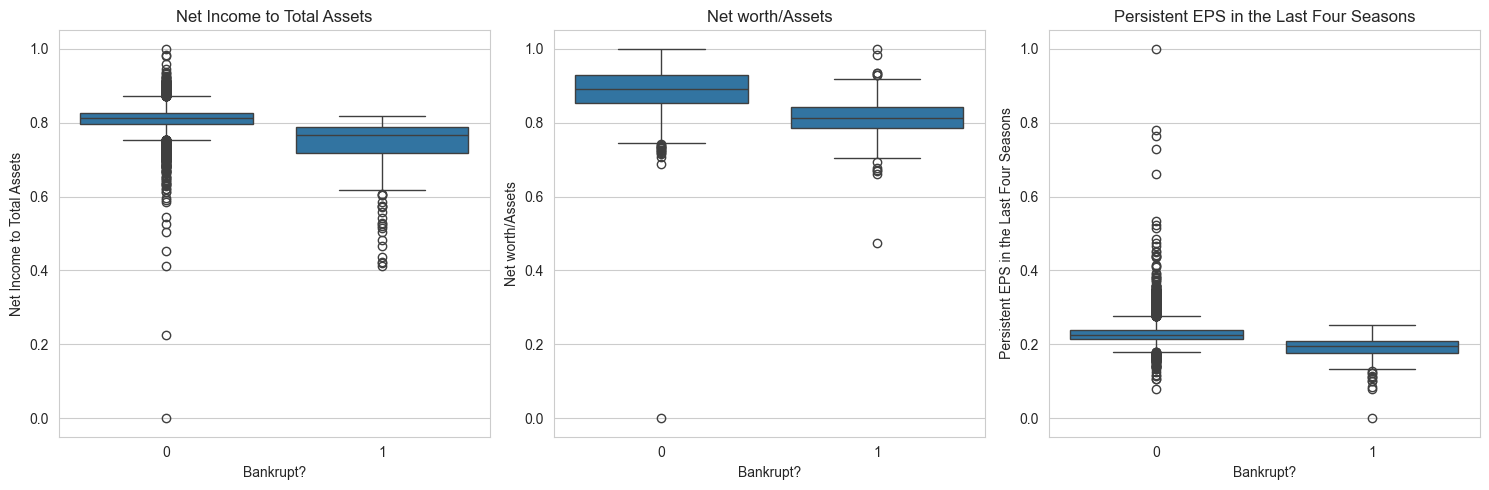

In [46]:
features = [
    'Net Income to Total Assets',
    'Net worth/Assets',
    'Persistent EPS in the Last Four Seasons'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features):
  sns.boxplot(x=df['Bankrupt?'], y=df[feature], ax=axes[i])
  axes[i].set_title(feature)

plt.tight_layout()

Comparing financial ratios between bankrupt and non-bankrupt companies shows a clear but not perfectly separating pattern. Net Income to Total Assets shows the strongest separation: healthy companies have a noticeably higher median (~0.82) than bankrupt ones (~0.75), reflecting the intuitive idea that lower profitability relative to assets is associated with higher bankruptcy risk. Net worth/Assets shows a similar but weaker pattern — healthy companies tend to rely less on debt to finance their assets. Persistent EPS shows the smallest difference between classes, with heavily overlapping distributions.

Importantly, none of these ratios separates the two classes perfectly on its own — the boxes are shifted relative to each other but still overlap substantially. This confirms that bankruptcy is not driven by a single financial ratio in isolation, but by a combination of factors, which is exactly why a machine learning model — capable of combining dozens of such signals — is well-suited for this problem, rather than a simple single-threshold rule.

In [47]:
top15_cols = top15_features.index.tolist()  # extract just the column names

plt.figure(figsize=(10, 8), dpi=120)
sns.heatmap(df[top15_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap of top-15 features (by correlation with target)')
plt.show()

KeyError: "['ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'ROA(C) before interest and depreciation before interest', 'Debt ratio %', 'Net profit before tax/Paid-in capital', 'Per Share Net profit before tax (Yuan Â¥)', 'Borrowing dependency'] not in index"

<Figure size 1200x960 with 0 Axes>

The heatmap confirms the multicollinearity findings numerically identified earlier. Profitability features (Net Income to Total Assets, ROA(A), ROA(B), ROA(C)) form a tight cluster with correlations of 0.89–0.99. Net worth/Assets and Debt ratio % show a perfect inverse correlation (-1.00), confirming they are mathematically equivalent (Net worth/Assets = 1 - Debt ratio). Per-share profit metrics (Persistent EPS, Net profit before tax/Paid-in capital, Per Share Net profit before tax) also cluster tightly (0.96). These visual clusters validate the decision to drop redundant features before modeling, keeping one representative per group.

**EDA Summary**
*   Class imbalance: the target is highly imbalanced (96.8% non-bankrupt vs 3.2% bankrupt), making accuracy an unreliable metric; evaluation will rely on recall, precision, F1, ROC-AUC, and PR-AUC instead.
*   Distributions and outliers: 48 of 94 features have |skew| > 10. Extreme values are mostly caused by ratios with near-zero denominators (e.g., Total debt/Total net worth reaching billions for companies with near-zero net worth) rather than data entry errors — these will be handled via percentile clipping rather than row removal, to avoid losing rare bankrupt cases.
*   Correlation with target: the strongest single-feature correlation is Net Income to Total Assets at -0.32 — a moderate-at-best linear relationship, indicating no single ratio separates bankrupt and healthy companies on its own.
*   Class-wise comparison (boxplots): bankrupt and non-bankrupt companies show shifted but overlapping distributions across key ratios, reinforcing that bankruptcy is driven by a combination of factors rather than any single metric.
*   Multicollinearity: 28 feature pairs with |corr| > 0.9 were identified, falling into 7 redundant feature groups (profitability, debt structure, profit-per-share, gross margin, interest rate, cash flow). 19 columns were selected for removal, keeping the most target-correlated or interpretable feature per group.